In [59]:
from pyproj import Transformer
from dem_stitcher.rio_window import read_raster_from_window
import matplotlib.pyplot as plt
from rasterio.crs import CRS
import rasterio
import numpy as np
import geopandas as gpd

In [22]:
xmin,ymin, xmax, ymax = -118.1688, 34.16368, -118.01825, 34.25 
bounds = xmin,ymin, xmax, ymax

In [32]:
metric_path = 'los_angeles_fires_2025/11SLT/OPERA_L3_DIST-ALERT-S1_T11SLT_20250121T135246Z_20251017T014008Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T11SLT_20250121T135246Z_20251017T014008Z_S1A_30_v0.1_GEN-METRIC.tif'

In [33]:
arr, p = read_raster_from_window(metric_path, bounds, CRS.from_epsg(4326))

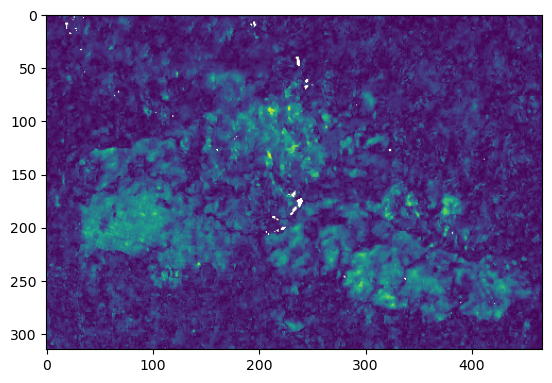

In [34]:
plt.imshow(arr[0])

In [81]:
colorized_rgb = 'subset_OPERA_L3_DIST-ALERT-S1_T11SLT_20250121T135246Z_20251017T014008Z_S1A_30_v0.1_GEN-METRIC.tif'

In [82]:
norm = np.clip((arr[0, ...] - 2) / (5 - 2), 0, 1)
norm[np.isnan(255)] = 0

cmap = plt.get_cmap("viridis")
rgb = (cmap(norm)[..., :3] * 255).astype(np.uint8)

p_rgb_metric = p.copy()
p_rgb_metric.update(count=3, dtype='uint8', nodata=None)
with rasterio.open(colorized_rgb, "w", **p_rgb_metric) as dst:
    for i in range(3):
        dst.write(rgb[..., i], i + 1)

In [84]:
!rio pmtiles {colorized_rgb} metric_20250121_subset_eaton.pmtiles --format PNG --resampling nearest --zoom-levels 5..17

100%|██████████████████████████████████████| 2988/2988 [00:05<00:00, 514.88it/s]


In [53]:
def indexed_to_rgb_robust(input_path, output_path):
    with rasterio.open(input_path) as src:
        colormap = src.colormap(1)
        if colormap is None:
            return

        indexed_data = src.read(1)

        max_index = max(colormap.keys())
        colormap_array = np.zeros((max_index + 1, 4), dtype=np.uint8)

        for index, rgba in colormap.items():
            colormap_array[index] = rgba

        rgb_rgba_data = colormap_array[indexed_data]

        rgb_data = rgb_rgba_data[:, :, :3].transpose(2, 0, 1)

        profile = src.profile
        profile.update(
            dtype=rasterio.uint8, 
            count=3,           
            nodata=None        
        )

        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(rgb_data, indexes=[1, 2, 3])
            print(f"Successfully converted and saved RGB file to {output_path}")

In [44]:
status_path = 'los_angeles_fires_2025/11SLT/OPERA_L3_DIST-ALERT-S1_T11SLT_20250303T140056Z_20251016T224900Z_S1A_30_v0.1/OPERA_L3_DIST-ALERT-S1_T11SLT_20250303T140056Z_20251016T224900Z_S1A_30_v0.1_GEN-DIST-STATUS.tif'

In [45]:
with rasterio.open(status_path) as ds:
    cmap = ds.colormap(1)

In [40]:
rgb_tiff = 'status_subset.tif'

In [48]:
arr_status, p_s = read_raster_from_window(status_path, bounds, CRS.from_epsg(4326))

In [49]:
out_status = 'OPERA_L3_DIST-ALERT-S1_T11SLT_20250303T140056Z_20251016T224900Z_S1A_30_v0.1_GEN-DIST-STATUS_subset.tif'

In [50]:
with rasterio.open(out_status, 'w', **p_s) as ds:
    ds.write(arr_status)
    ds.write_colormap(1, cmap)

In [56]:
indexed_to_rgb_robust(out_status, rgb_tiff)

Successfully converted and saved RGB file to status_subset.tif


In [57]:
!rio pmtiles {rgb_tiff} eaton_fire_2025_status.pmtiles --format PNG --resampling nearest --zoom-levels 5..17

100%|██████████████████████████████████████| 2988/2988 [00:05<00:00, 546.14it/s]


In [88]:
df = gpd.read_file('DINS_2025_Eaton_Public_View/')

In [89]:
df_f = df.rename(columns={'DAMAGE': 'Damage', 'STRUCTURET': 'Structure'})[['Structure', 'Damage', 'geometry']].copy()
df_f = df_f.to_crs('4326')
df_f.to_file('dins_eaton_formatted.geojson', driver='GeoJSON')

In [90]:
df_fire = gpd.read_file('los_angeles_fires.geojson')
df_eaton = df_fire[df_fire['fire_name'] == 'eaton'].reset_index(drop=True)
df_eaton.to_file('eaton_perimeter.geojson')

<Axes: >

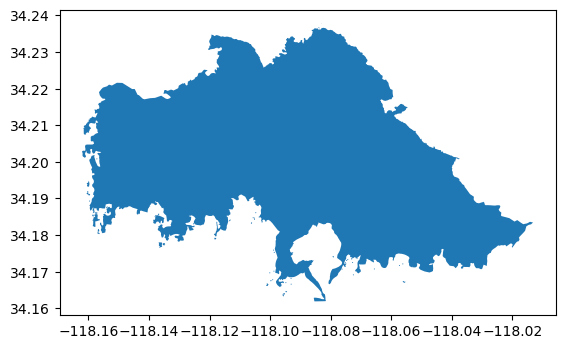

In [91]:
df_eaton.plot()